In [3]:
# Import libraries
import arcpy
import numpy as np
import pandas as pd

# Reference a project
project = arcpy.mp.ArcGISProject("CURRENT")

# Set environment settings
arcpy.env.workspace = r"C:\GEOG6480\Lab04\Lab04.gdb"
nad83_utm17n = arcpy.SpatialReference(26917)
arcpy.env.outputCoordinateSystem = nad83_utm17n
arcpy.env.overwriteOutput = True

In [13]:
# A function to read an attribute table as pandas dataframe
def table_to_dataframe(feature_class: str) -> pd.DataFrame:
    field_names: list[str] = [field.name for field in arcpy.ListFields(feature_class)]
    return pd.DataFrame(
        (row for row in arcpy.da.SearchCursor(
            in_table=feature_class, 
            field_names=field_names, 
            where_clause="")
        ), 
        columns=field_names
    )

In [2]:
# Project the PopAge data (from Lambert Conformal Conic to UTM 17N)
fc_guelph_popage_utm17n: str = "Guelph_PopAge_UTM17N"
arcpy.management.Project(
    in_dataset="lda_000b21f_e__PopAge", 
    out_dataset=fc_guelph_popage_utm17n, 
    out_coor_system=nad83_utm17n
)

<Result 'C:\\GEOG6480\\Lab04\\Lab04.gdb\\Guelph_PopAge_UTM17N'>

In [3]:
# Show table properties
fields = arcpy.ListFields(fc_guelph_popage_utm17n)
for field in fields:
    print(f"{field.name} has a type of {field.type} with a length of {field.length}")

# Set local variables
field_name: str = "pop_per_dwelling"
code_block: str = """
from typing import Optional
def calc_pop_per_dwelling(
    population: int, 
    dwellings: int, 
) -> Optional[float]:
    if dwellings == 0:
        return None
    return population / dwellings
"""
expression: str = """
calc_pop_per_dwelling(
    population=!Population_and_dwelling_counts__5___Population__2021__1_!, 
    dwellings=!Population_and_dwelling_counts__5___Private_dwellings_occupied_b!
)
"""

# Run AddField
arcpy.management.AddField(
    in_table=fc_guelph_popage_utm17n, 
    field_name=field_name,
    field_type="DOUBLE"
)

# Calculate population per dwelling
arcpy.management.CalculateField(
    in_table=fc_guelph_popage_utm17n, 
    field=field_name, 
    expression=expression, 
    expression_type="PYTHON3", 
    code_block=code_block, 
    # {field_type}, 
    # {enforce_domains}
)

OBJECTID_12 has a type of OID with a length of 4
Shape has a type of Geometry with a length of 0
Population_and_dwelling_counts__5___Population__2021__1_ has a type of Integer with a length of 4
Population_and_dwelling_counts__5___Private_dwellings_occupied_b has a type of Integer with a length of 4
Shape_Length has a type of Double with a length of 8
Shape_Area has a type of Double with a length of 8


<Result 'Guelph_PopAge_UTM17N'>

In [4]:
# Create a raster for popular per dwelling
arcpy.conversion.PolygonToRaster(
    in_features=fc_guelph_popage_utm17n, 
    value_field=field_name, 
    out_rasterdataset="Guelph_PopPerDwelling", 
    cell_assignment="CELL_CENTER", 
    priority_field=field_name, 
    # {cellsize}, 
    # {build_rat}
)

<Result 'C:\\GEOG6480\\Lab04\\Lab04.gdb\\Guelph_PopPerDwelling'>

In [5]:
# Set all the items of Conceptualization_of_Spatial_Relationships
conceptualizations: list[str] = [
    "INVERSE_DISTANCE",
    "INVERSE_DISTANCE_SQUARED",
    "FIXED_DISTANCE_BAND",
    "ZONE_OF_INDIFFERENCE",
    "K_NEAREST_NEIGHBORS",
    "CONTIGUITY_EDGES_ONLY",
    "CONTIGUITY_EDGES_CORNERS",
    # "GET_SPATIAL_WEIGHTS_FROM_FILE"
]
# Run Spatial Autocorrelation for all the conceptualizations
for c in conceptualizations:
    arcpy.stats.SpatialAutocorrelation(
        Input_Feature_Class=fc_guelph_popage_utm17n, 
        Input_Field=field_name, 
        Generate_Report="GENERATE_REPORT", 
        Conceptualization_of_Spatial_Relationships=c, 
        Distance_Method="EUCLIDEAN_DISTANCE", 
        Standardization="ROW", 
        # {Distance_Band_or_Threshold_Distance}, 
        # {Weights_Matrix_File}, 
        # {number_of_neighbors}
    )

In [6]:
# Run Hot Spot Analysis (Getis-Ord Gi*) for all the conceptualizations
for c in conceptualizations:
    out_hotspot: str = f"HotSpots_{c}"
    arcpy.stats.HotSpots(
        Input_Feature_Class=fc_guelph_popage_utm17n, 
        Input_Field=field_name, 
        Output_Feature_Class=out_hotspot, 
        Conceptualization_of_Spatial_Relationships=c, 
        Distance_Method="EUCLIDEAN_DISTANCE", 
        Standardization="ROW", 
        # {Distance_Band_or_Threshold_Distance}, 
        # {Self_Potential_Field}, 
        # {Weights_Matrix_File}, 
        # {Apply_False_Discovery_Rate__FDR__Correction}, 
        # {number_of_neighbors}
    )

In [7]:
# Run Hot Spot Analysis with different bands of FIXED_DISTANCE_BAND
out_hotspot_list: list[str] = []
for i in range(500, 10501, 500):
    out_hotspot: str = f"HotSpots_FDB_{i:05}"
    out_hotspot_list.append(out_hotspot)
    print(f"{out_hotspot}...")
    arcpy.stats.HotSpots(
        Input_Feature_Class=fc_guelph_popage_utm17n, 
        Input_Field=field_name, 
        Output_Feature_Class=out_hotspot, 
        Conceptualization_of_Spatial_Relationships="FIXED_DISTANCE_BAND", 
        Distance_Method="EUCLIDEAN_DISTANCE", 
        Standardization="ROW", 
        Distance_Band_or_Threshold_Distance=i, 
    )

HotSpots_FDB_00500...
HotSpots_FDB_01000...
HotSpots_FDB_01500...
HotSpots_FDB_02000...
HotSpots_FDB_02500...
HotSpots_FDB_03000...
HotSpots_FDB_03500...
HotSpots_FDB_04000...
HotSpots_FDB_04500...
HotSpots_FDB_05000...
HotSpots_FDB_05500...
HotSpots_FDB_06000...
HotSpots_FDB_06500...
HotSpots_FDB_07000...
HotSpots_FDB_07500...
HotSpots_FDB_08000...
HotSpots_FDB_08500...
HotSpots_FDB_09000...
HotSpots_FDB_09500...
HotSpots_FDB_10000...
HotSpots_FDB_10500...


In [19]:
# Read all the hotspot feature classes for the threshold range
hotspot_df_dict: dict[str, pd.DataFrame] = dict()
for hs in out_hotspot_list:
    hotspot_df_dict[hs] = table_to_dataframe(feature_class=hs)

In [28]:
# Create a dataframe including significantly hot and cold counts
hot_cold_threshold_df = pd.DataFrame(columns=["threshold", "hot", "cold", "total"])
for name, df in hotspot_df_dict.items():
    hot: int = df[df["Gi_Bin"] > 0].shape[0]
    cold: int = df[df["Gi_Bin"] < 0].shape[0]    
    hot_cold_threshold_df.loc[len(hot_cold_threshold_df)] = [
        int(name[-5:]), 
        hot, 
        cold, 
        hot + cold
    ]

hot_cold_threshold_df

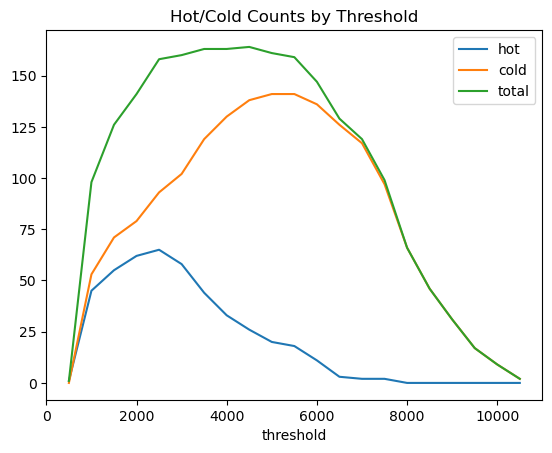

In [29]:
# Line plot 
ax = hot_cold_threshold_df.plot(
    x="threshold", 
    y=["hot", "cold", "total"], 
    kind="line", 
    title="Hot/Cold Counts by Threshold", 
    legend=True
)
ax.figure.savefig("hot-cold-threshold.pdf")

In [39]:
# Print the maximum of each property
print(
    f"hot-max: {hot_cold_threshold_df.iloc[hot_cold_threshold_df['hot'].idxmax()].iloc[0]}"
)
print(
    f"cold-max: {hot_cold_threshold_df.iloc[hot_cold_threshold_df['cold'].idxmax()].iloc[0]}"
)
print(
    f"total-max: {hot_cold_threshold_df.iloc[hot_cold_threshold_df['total'].idxmax()].iloc[0]}"
)

hot-max: 2500
cold-max: 5000
total-max: 4500
